In [ ]:
# images_long_df.to_csv('data/profiles_long.csv', index=False)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/profiles_features.csv')

In [10]:
df = df[df['modality'] == 'autofluorescence']

In [11]:
df['id_region'] = df['brain_id'] + '_' + df['region']
df['region_id'] = df['region'] + '_' + df['brain_id']

In [12]:
df["Features"] = df["Features"].apply(lambda s: [float(x) for x in s.strip("[]").split()])

In [13]:
df['id_region']

91          B07_A2
92          B07_A2
93          B07_A2
94     B07_ANTCING
95     B07_ANTCING
96     B07_ANTCING
97       B07_BROCA
98       B07_BROCA
99       B07_BROCA
100     B07_INSULA
101     B07_INSULA
102     B07_INSULA
103         B07_M1
104         B07_M1
105         B07_M1
106    B07_POSCING
107    B07_POSCING
108    B07_POSCING
109         B07_S1
110         B07_S1
111         B07_S1
112       B07_V2V3
113       B07_V2V3
114       B07_V2V3
115         B13_A1
116         B13_A1
117         B13_A1
118         B13_A2
119         B13_A2
120         B13_A2
121      B13_BROCA
122      B13_BROCA
123      B13_BROCA
124     B13_INSULA
125     B13_INSULA
126     B13_INSULA
127         B13_M1
128         B13_M1
129         B13_M1
130    B13_POSCING
131    B13_POSCING
132    B13_POSCING
133         B13_S1
134         B13_S1
135         B13_S1
136       B13_V1V2
137       B13_V1V2
138       B13_V1V2
Name: id_region, dtype: str

In [14]:
from scipy.spatial.distance import mahalanobis
import numpy as np

# stack the arrays into a matrix
feat_matrix = np.stack(df["Features"].values) # shape (n, 10)

# compute covariance and invert
cov = np.cov(feat_matrix, rowvar=False)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = np.linalg.inv(cov)

# pairwise distances
from scipy.spatial.distance import pdist, squareform

D = squareform(pdist(feat_matrix, metric="mahalanobis", VI=cov_inv))

<Axes: >

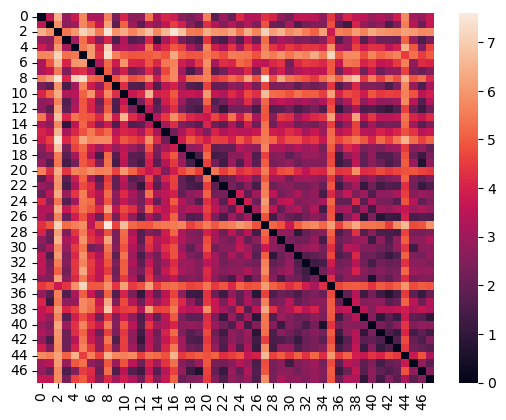

In [15]:
sns.heatmap(D)

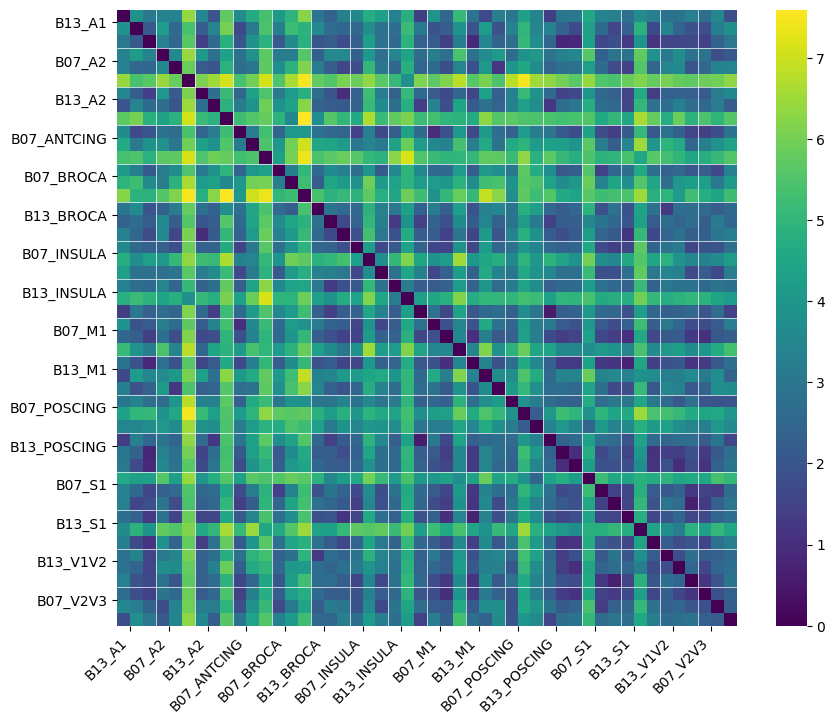

In [16]:
region_labels = df["id_region"].values

# sort by region so same-region profiles are adjacent
order = df["region_id"].argsort()  # or np.argsort(region_labels)
D_sorted = D[np.ix_(order, order)]
sorted_regions = region_labels[order]

# find midpoint of each region's block for tick placement
unique_regions = []
tick_positions = []
prev = None
start = 0
for i, r in enumerate(sorted_regions):
    if r != prev:
        if prev is not None:
            tick_positions.append((start + i - 1) / 2)
            unique_regions.append(prev)
        start = i
        prev = r
tick_positions.append((start + len(sorted_regions) - 1) / 2)
unique_regions.append(prev)

# plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(D_sorted, ax=ax, cmap="viridis", xticklabels=False, yticklabels=False)

ax.set_xticks(tick_positions)
ax.set_xticklabels(unique_regions, rotation=45, ha="right")
ax.set_yticks(tick_positions)
ax.set_yticklabels(unique_regions, rotation=0)

# draw lines at region boundaries
boundaries = np.where(sorted_regions[:-1] != sorted_regions[1:])[0] + 1
for b in boundaries:
    ax.axhline(b, color="white", linewidth=0.5)
    ax.axvline(b, color="white", linewidth=0.5)

In [17]:
from skbio.stats.distance import DistanceMatrix

dm = DistanceMatrix(D, ids=df.index)

In [18]:
from skbio.stats.distance import permanova

result = permanova(dm, grouping=df["id_region"], permutations=9999)
print(result)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      48
number of groups                 16
test statistic             1.427557
p-value                      0.0052
number of permutations         9999
Name: PERMANOVA results, dtype: object


c:\Users\P70089795\AppData\Local\miniforge3\envs\napari-env\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\P70089795\AppData\Local\miniforge3\envs\napari-env\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\P70089795\AppData\Local\miniforge3\envs\napari-env\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Text(0, 0.5, 'MDS 2')

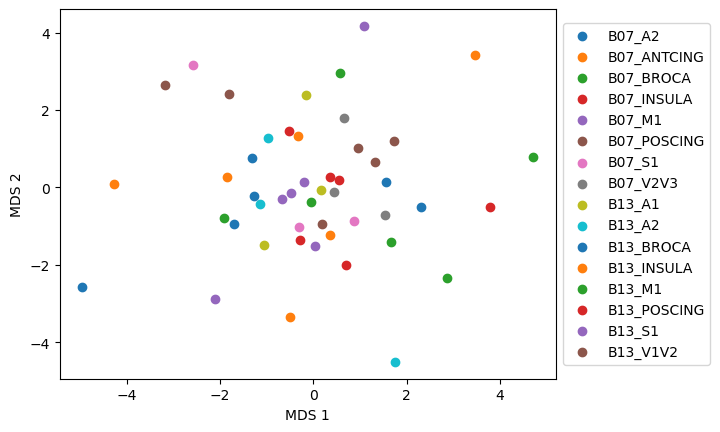

In [19]:
from sklearn.manifold import MDS

embedding = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = embedding.fit_transform(D)

import matplotlib.pyplot as plt
for region in df["id_region"].unique():
    mask = df["id_region"] == region
    plt.scatter(coords[mask, 0], coords[mask, 1], label=region)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")

Text(0, 0.5, 'PC2 (5%)')

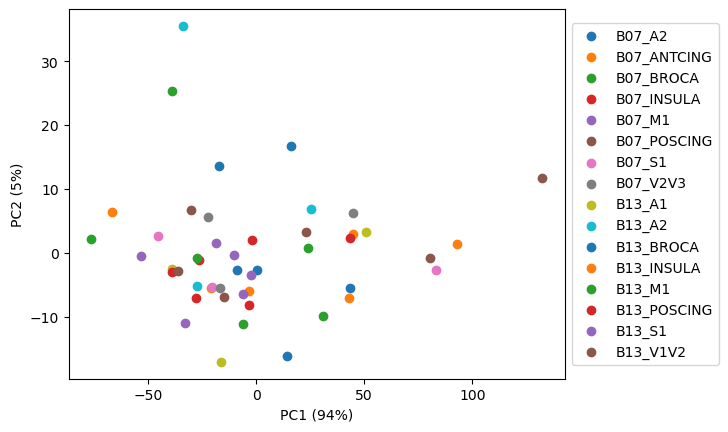

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

feat_matrix = np.stack(df["Features"].values)
pca = PCA(n_components=2)
scores = pca.fit_transform(feat_matrix)

for region in df["id_region"].unique():
    mask = df["id_region"] == region
    plt.scatter(scores[mask, 0], scores[mask, 1], label=region)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")

In [21]:
# multivariate ttests between all combinations fail, too many variables (10) for too little points

import pingouin as pg
import numpy as np
from itertools import combinations

# expand the feature arrays into a DataFrame with columns
feat_matrix = np.stack(df["Features"].values)
feat_df = pd.DataFrame(feat_matrix, columns=[f"f{i}" for i in range(10)])
feat_df["id_region"] = df["id_region"].values

# pairwise Hotelling T² tests
feature_cols = [f"f{i}" for i in range(10)]
regions = feat_df["id_region"].unique()

results = []
for r1, r2 in combinations(regions, 2):
    X = feat_df.loc[feat_df["id_region"] == r1, feature_cols]
    Y = feat_df.loc[feat_df["id_region"] == r2, feature_cols]
    res = pg.multivariate_ttest(X, Y)
    results.append({"r1": r1, "r2": r2, **res.iloc[0].to_dict()})

results_df = pd.DataFrame(results)

# Bonferroni correction
results_df["pval_corrected"] = np.minimum(results_df["pval"] * len(results_df), 1.0)



AssertionError: At least five samples are required.

In [22]:
# we reduce the amount of features using PCA
import pingouin as pg
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.decomposition import PCA

# PCA on features
feat_matrix = np.stack(df["Features"].values)
pca = PCA(n_components=3)
scores = pca.fit_transform(feat_matrix)

feat_df = pd.DataFrame(scores, columns=["PC1", "PC2", "PC3"])
feat_df["id_region"] = df["id_region"].values

# pairwise Hotelling T²
feature_cols = ["PC1", "PC2", "PC3"]
regions = feat_df["id_region"].unique()

results = []
for r1, r2 in combinations(regions, 2):
    X = feat_df.loc[feat_df["id_region"] == r1, feature_cols]
    Y = feat_df.loc[feat_df["id_region"] == r2, feature_cols]
    res = pg.multivariate_ttest(X, Y)
    results.append({"r1": r1, "r2": r2, **res.iloc[0].to_dict()})

results_df = pd.DataFrame(results)
results_df["pval_corrected"] = np.minimum(results_df["pval"] * len(results_df), 1.0)

AssertionError: At least five samples are required.

In [23]:
feat_df

,PC1,PC2,PC3,id_region
0,16.108306,16.785848,-0.169063,B07_A2
1,0.391043,-2.686643,6.474534,B07_A2
2,14.251009,-16.207652,-3.561855,B07_A2
3,-3.595774,-5.966916,2.609356,B07_ANTCING
4,-21.151136,-5.567330,2.396209,B07_ANTCING
5,-66.581602,6.433805,-11.098820,B07_ANTCING
6,-38.903375,25.383459,1.091259,B07_BROCA
7,-76.410275,2.107835,-2.544539,B07_BROCA
8,30.843205,-9.865350,3.961230,B07_BROCA
9,-1.912582,2.003399,6.043163,B07_INSULA


In [24]:
results_df[results_df['pval_corrected'] < 0.05]

NameError: name 'results_df' is not defined

In [25]:
import networkx as nx
G= nx.from_pandas_edgelist(results_df, "r1", "r2")

nx.draw(G, with_labels=True)
plt.show()

NameError: name 'results_df' is not defined

In [26]:
# mean Mahalanobis distance per region to all others
region_labels = df["id_region"].values
unique_regions = np.unique(region_labels)

mean_distances = {}
for region in unique_regions:
    mask_self = region_labels == region
    mask_other = ~mask_self
    # mean distance from this region's profiles to all other profiles
    mean_distances[region] = D[np.ix_(mask_self, mask_other)].mean()

ranking = pd.Series(mean_distances).sort_values(ascending=False)
print(ranking)

B07_BROCA      4.377535
B07_A2         4.221517
B07_ANTCING    4.143723
B07_POSCING    4.048421
B13_A2         3.855475
B13_INSULA     3.690367
B07_INSULA     3.601582
B13_S1         3.513643
B07_S1         3.409604
B07_M1         3.319902
B13_M1         3.314747
B13_A1         3.158508
B13_BROCA      3.071633
B07_V2V3       3.030587
B13_V1V2       3.002094
B13_POSCING    2.898506
dtype: float64
